### Covid - 19 Project

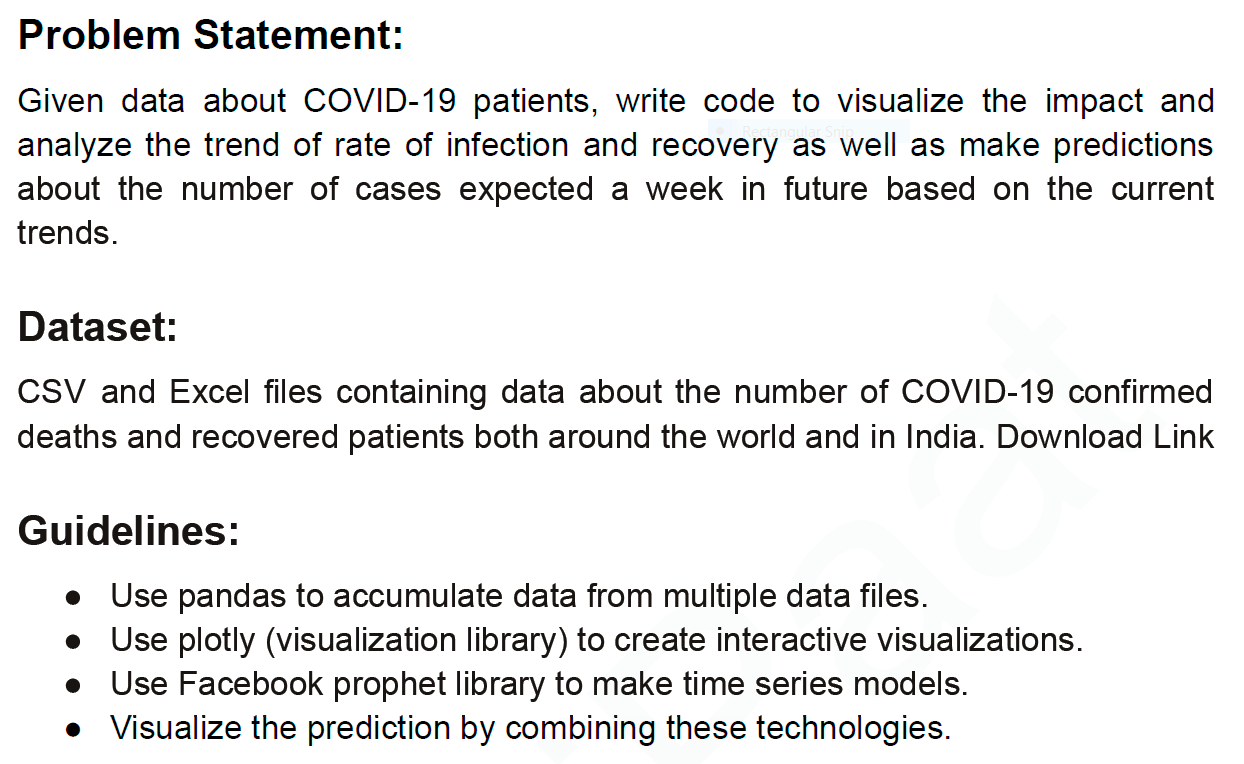

<hr>
Importing Libraries and data set file
<hr>

In [183]:
# Importing basic Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

import warnings
warnings.filterwarnings("ignore")
def fxn():
    warnings.warn("deprecated", DeprecationWarning)
with warnings.catch_warnings(action="ignore"):
    fxn()

In [184]:
filepath = r'D:\Harpreet\Documents\Learning\Intellipaat- DS & AI 2025\ML\Covid-19 Project\covid_19_clean_complete.csv'
covid19_df = pd.read_csv(filepath)
covid19_df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


<hr>
EDA
<hr>

In [185]:
# Firstly we get a date index to begin with

covid19_df['Date']= pd.to_datetime(covid19_df['Date'], errors='coerce', format="%Y-%m-%d")  # converts the Date object to datetime format
                                                                                            # included the format parameter to avoid errors moving forward
covid19_df.set_index("Date", inplace=True)     # make the Date column as the index
# covid19_df.sort_index(inplace=True, ascending=True)    # sort as per ascending order

covid19_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 49068 entries, 2020-01-22 to 2020-07-27
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Confirmed       49068 non-null  int64  
 5   Deaths          49068 non-null  int64  
 6   Recovered       49068 non-null  int64  
 7   Active          49068 non-null  int64  
 8   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [186]:
# Checking for duplicates or Null values

print(f"Duplicate items = {covid19_df.duplicated().sum()}")
print("---------------------")
print(f"Null Items : \n{covid19_df.isnull().sum()}")

Duplicate items = 23104
---------------------
Null Items : 
Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64


There are several Nulls in the Province/State column. We cannot remove that because as per observations in the original data file, several countries dont have a state mentioned. For now, we will keep the data as is and split later on using *groupby*

In [187]:
covid19_df.head()

,Province/State,Country/Region,Lat,Long,Confirmed,Deaths,Recovered,Active,WHO Region
Date,,,,,,,,,
2020-01-22,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,Eastern Mediterranean
2020-01-22,NaN,Albania,41.15330,20.168300,0,0,0,0,Europe
2020-01-22,NaN,Algeria,28.03390,1.659600,0,0,0,0,Africa
2020-01-22,NaN,Andorra,42.50630,1.521800,0,0,0,0,Europe
2020-01-22,NaN,Angola,-11.20270,17.873900,0,0,0,0,Africa


#### Datewise

<hr>
Date-Wise organizing and indexing, grouping as per dates
<hr>

In [188]:
covid19_df.index.value_counts()

Date
2020-01-22    261
2020-01-23    261
2020-01-24    261
2020-01-25    261
2020-01-26    261
             ... 
2020-07-23    261
2020-07-24    261
2020-07-25    261
2020-07-26    261
2020-07-27    261
Name: count, Length: 188, dtype: int64

In [189]:
# The Uniqie values in each column

covid19_df[covid19_df.duplicated()].nunique()

Province/State      78
Country/Region     187
Lat                260
Long               261
Confirmed         1040
Deaths             204
Recovered          819
Active             700
WHO Region           6
dtype: int64

As on 27-07-2020, total number of Active Cases registered around the world are 396715350; out of which 388408229 patients are recorded to have completely recovered.
 But unfortunately 43384903 patients did not survive the virus due to varrious reasons.


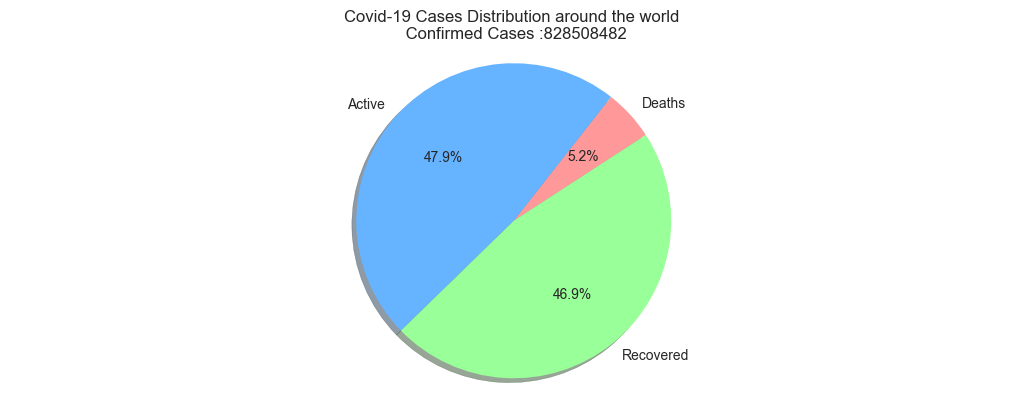

In [190]:
print(f"As on {covid19_df.index.max().strftime('%d-%m-%Y')}, total number of Active Cases registered around the world are {covid19_df['Active'].sum()}; out of which {covid19_df['Recovered'].sum()} patients are recorded to have completely recovered.\n But unfortunately {covid19_df['Deaths'].sum()} patients did not survive the virus due to varrious reasons.")

plt.figure(figsize=(13,4.5))

d=(covid19_df['Deaths'].sum() / covid19_df['Confirmed'].sum())*100
a=(covid19_df['Active'].sum() / covid19_df['Confirmed'].sum())*100
r=(covid19_df['Recovered'].sum() / covid19_df['Confirmed'].sum())*100

labels = ['Deaths', 'Active', 'Recovered']
sizes = [d, a, r]  # percentage values
colors = ['#ff9999', '#66b3ff', '#99ff99']
explode = (0.008, 0.04, 0.04)  # slight separation for each slice

# Create pie chart
plt.pie(sizes,
        labels= labels,
        colors= colors,
        autopct= '%1.1f%%',
        startangle= 33,
   #     explode=explode,
        shadow=True)

plt.title(f'Covid-19 Cases Distribution around the world \n Confirmed Cases :{covid19_df['Confirmed'].sum()}')
plt.axis('equal')  # Equal aspect ratio ensures the pie is circular
plt.show()

In [191]:
date_range= covid19_df.index.max() - covid19_df.index.min() # this process is on datetime dtype. so return type is number of days (i.e. datetime type)
date_range= int(date_range.days)        # convert from datetime to int
print(f"In the recorded {date_range} days, {covid19_df['Active'].sum()} cases were registered Active; i.e. on a average, approximately {int(covid19_df['Active'].sum()/date_range)} cases per day.")


In the recorded 187 days, 396715350 cases were registered Active; i.e. on a average, approximately 2121472 cases per day.


In [192]:
datewise_toll_df= covid19_df.groupby(covid19_df.index)[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum()
print(f"This is a World-wide Tolls of recorded cases each day.")
datewise_toll_df

This is a World-wide Tolls of recorded cases each day.


,Confirmed,Deaths,Recovered,Active
Date,,,,
2020-01-22,555,17,28,510
2020-01-23,654,18,30,606
2020-01-24,941,26,36,879
2020-01-25,1434,42,39,1353
2020-01-26,2118,56,52,2010
...,...,...,...,...
2020-07-23,15510481,633506,8710969,6166006
2020-07-24,15791645,639650,8939705,6212290
2020-07-25,16047190,644517,9158743,6243930


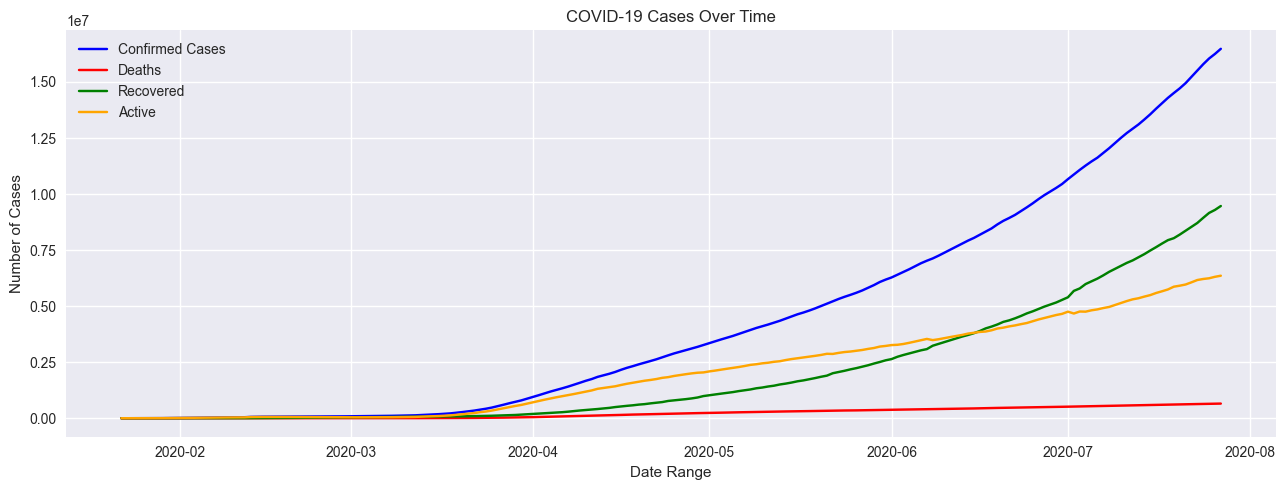

In [193]:
# Set the plot style
plt.style.use('seaborn-v0_8')

# Create the plot
plt.figure(figsize=(13, 5))
plt.plot(datewise_toll_df.index, datewise_toll_df['Confirmed'], label='Confirmed Cases', color='blue')
plt.plot(datewise_toll_df.index, datewise_toll_df['Deaths'], label='Deaths', color='red')
plt.plot(datewise_toll_df.index, datewise_toll_df['Recovered'], label='Recovered', color='green')
plt.plot(datewise_toll_df.index, datewise_toll_df['Active'], label='Active', color='orange')

# Add labels and title
plt.xlabel('Date Range')
plt.ylabel('Number of Cases')
plt.title('COVID-19 Cases Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<hr>

#### Analysis - Location-wise

<hr>
Location-wise organizing the data to visualize the effect over the world
<hr>

We need to group multiple rows and see a total count for each country/province as applicable. So we use *groupby...aggregation* functions to perform the segregations.

In [194]:
groupwise_toll_df= covid19_df.groupby(['Country/Region', 'Province/State']).agg(tot_Conf= ('Confirmed', 'sum'),
                                                                                tot_Deaths= ('Deaths', 'sum'),
                                                                                tot_Recovered= ('Recovered', 'sum'),
                                                                                tot_Active= ('Active', 'sum'))
groupwise_toll_df

tot_Conf  tot_Deaths  \
Country/Region Province/State                                       
Australia      Australian Capital Territory     13174         339   
               New South Wales                 384636        5055   
               Northern Territory                3537           0   
               Queensland                      129172         694   
               South Australia                  54273         440   
...                                               ...         ...   
United Kingdom Falkland Islands (Malvinas)       1383           0   
               Gibraltar                        18999           0   
               Isle of Man                      36872        2323   
               Montserrat                        1309          95   
               Turks and Caicos Islands          2989         142   

                                             tot_Recovered  tot_Active  
Country/Region Province/State                                           
Australia      Australian Capital Territory          11264        1571  
               New South Wales                      269428      110153  
               Northern Territory                     2794         743  
               Queensland                           106911       21567  
               South Australia                       45793        8040  
...                                                    ...         ...  
United Kingdom Falkland Islands (Malvinas)            1257         126  
               Gibraltar                             17306        1693  
               Isle of Man                           31037        3512  
               Montserrat                              864         350  
               Turks and Caicos Islands               1093        1754  

[78 rows x 4 columns]

In [195]:
# Highes record of deaths overall
groupwise_toll_df[groupwise_toll_df['tot_Deaths']== groupwise_toll_df['tot_Deaths'].max()]

,,tot_Conf,tot_Deaths,tot_Recovered,tot_Active
Country/Region,Province/State,,,,
China,Hubei,11473248,651932,9387518,1433798


In [196]:
# Least deaths / 0 deaths overall
groupwise_toll_df[groupwise_toll_df['tot_Deaths']== groupwise_toll_df['tot_Deaths'].min()].sort_values(by='tot_Recovered', ascending=False)

tot_Conf  tot_Deaths  \
Country/Region Province/State                                      
China          Jiangsu                        112469           0   
               Shanxi                          30441           0   
Denmark        Faroe Islands                   23897           0   
United Kingdom Gibraltar                       18999           0   
China          Ningxia                         12932           0   
France         French Polynesia                 7213           0   
China          Macau                            6217           0   
               Qinghai                          3215           0   
Australia      Northern Territory               3537           0   
France         New Caledonia                    2435           0   
Greenland      Greenland                        1507           0   
United Kingdom Falkland Islands (Malvinas)      1383           0   
France         Saint Barthelemy                  793           0   
United Kingdom Anguilla                          361           0   
China          Tibet                             180           0   
France         Saint Pierre and Miquelon         154           0   
Canada         Northwest Territories             585           0   
               Yukon                            1276           0   

                                            tot_Recovered  tot_Active  
Country/Region Province/State                                          
China          Jiangsu                             102367       10102  
               Shanxi                               27088        3353  
Denmark        Faroe Islands                        21424        2473  
United Kingdom Gibraltar                            17306        1693  
China          Ningxia                              12026         906  
France         French Polynesia                      5634        1579  
China          Macau                                 4853        1364  
               Qinghai                               2984         231  
Australia      Northern Territory                    2794         743  
France         New Caledonia                         1971         464  
Greenland      Greenland                             1372         135  
United Kingdom Falkland Islands (Malvinas)           1257         126  
France         Saint Barthelemy                       640         153  
United Kingdom Anguilla                               290          71  
China          Tibet                                  167          13  
France         Saint Pierre and Miquelon               78          76  
Canada         Northwest Territories                    0         585  
               Yukon                                    0        1276

<hr>

In [197]:
# Most recovered cases indicate that the medical facilities in these regions are well developed to adapt to the newer streams of the virus.

Q= groupwise_toll_df['tot_Recovered'].quantile(0.65)   # Selecting the Top 65% recovery rate amongst the facilities

top65= groupwise_toll_df[groupwise_toll_df['tot_Recovered']>= Q].sort_values(by='tot_Recovered', ascending=False)
top65

tot_Conf  tot_Deaths  tot_Recovered  \
Country/Region Province/State                                           
China          Hubei              11473248      651932        9387518   
Australia      New South Wales      384636        5055         269428   
China          Guangdong            268051        1273         237110   
               Zhejiang             220824         159         198777   
Australia      Victoria             279524        2526         195925   
China          Hunan                178641         662         162439   
               Anhui                172497        1007         155768   
France         Mayotte              189436        2403         149661   
China          Jiangxi              162963         169         147655   
France         French Guiana        226554         994         123808   
China          Shandong             132944        1103         118227   
               Hong Kong            151541         814         113725   
               Heilongjiang         131961        2196         111670   
Australia      Queensland           129172         694         106911   
China          Jiangsu              112469           0         102367   
               Chongqing            101756        1013          90135   
               Shanghai             100089         983          86680   
               Sichuan               98075         507          86306   
               Beijing              108512        1383          83847   
Australia      Western Australia     70669        1005          59833   
China          Fujian                59855         159          52936   
United Kingdom Channel Islands       63326        4579          48080   
Australia      South Australia       54273         440          45793   
China          Shaanxi               49821         430          43805   
France         Reunion               57863         124          42885   
China          Guangxi               44368         336          38927   
United Kingdom Isle of Man           36872        2323          31037   

                                  tot_Active  
Country/Region Province/State                 
China          Hubei                 1433798  
Australia      New South Wales        110153  
China          Guangdong               29668  
               Zhejiang                21888  
Australia      Victoria                81073  
China          Hunan                   15540  
               Anhui                   15722  
France         Mayotte                 37372  
China          Jiangxi                 15139  
France         French Guiana          101752  
China          Shandong                13614  
               Hong Kong               37002  
               Heilongjiang            18095  
Australia      Queensland              21567  
China          Jiangsu                 10102  
               Chongqing               10608  
               Shanghai                12426  
               Sichuan                 11262  
               Beijing                 23282  
Australia      Western Australia        9831  
China          Fujian                   6760  
United Kingdom Channel Islands         10667  
Australia      South Australia          8040  
China          Shaanxi                  5586  
France         Reunion                 14854  
China          Guangxi                  5105  
United Kingdom Isle of Man              3512

The above list contains the names of states where more than 65% have recovered patients. This is an indication that these states have better facilities to handle the Covid Cases and perhaps others can take similar measures.

*Strangely though, it looks like China/Hubei's figures seem extremely elevated.* In later operations, we may have to handle that as well.

In [198]:
# flatten the multi-index for making further visualizations
top65.reset_index(inplace=True)
top65

,Country/Region,Province/State,tot_Conf,tot_Deaths,tot_Recovered,tot_Active
0,China,Hubei,11473248,651932,9387518,1433798
1,Australia,New South Wales,384636,5055,269428,110153
2,China,Guangdong,268051,1273,237110,29668
3,China,Zhejiang,220824,159,198777,21888
4,Australia,Victoria,279524,2526,195925,81073
5,China,Hunan,178641,662,162439,15540
6,China,Anhui,172497,1007,155768,15722
7,France,Mayotte,189436,2403,149661,37372
8,China,Jiangxi,162963,169,147655,15139
9,France,French Guiana,226554,994,123808,101752


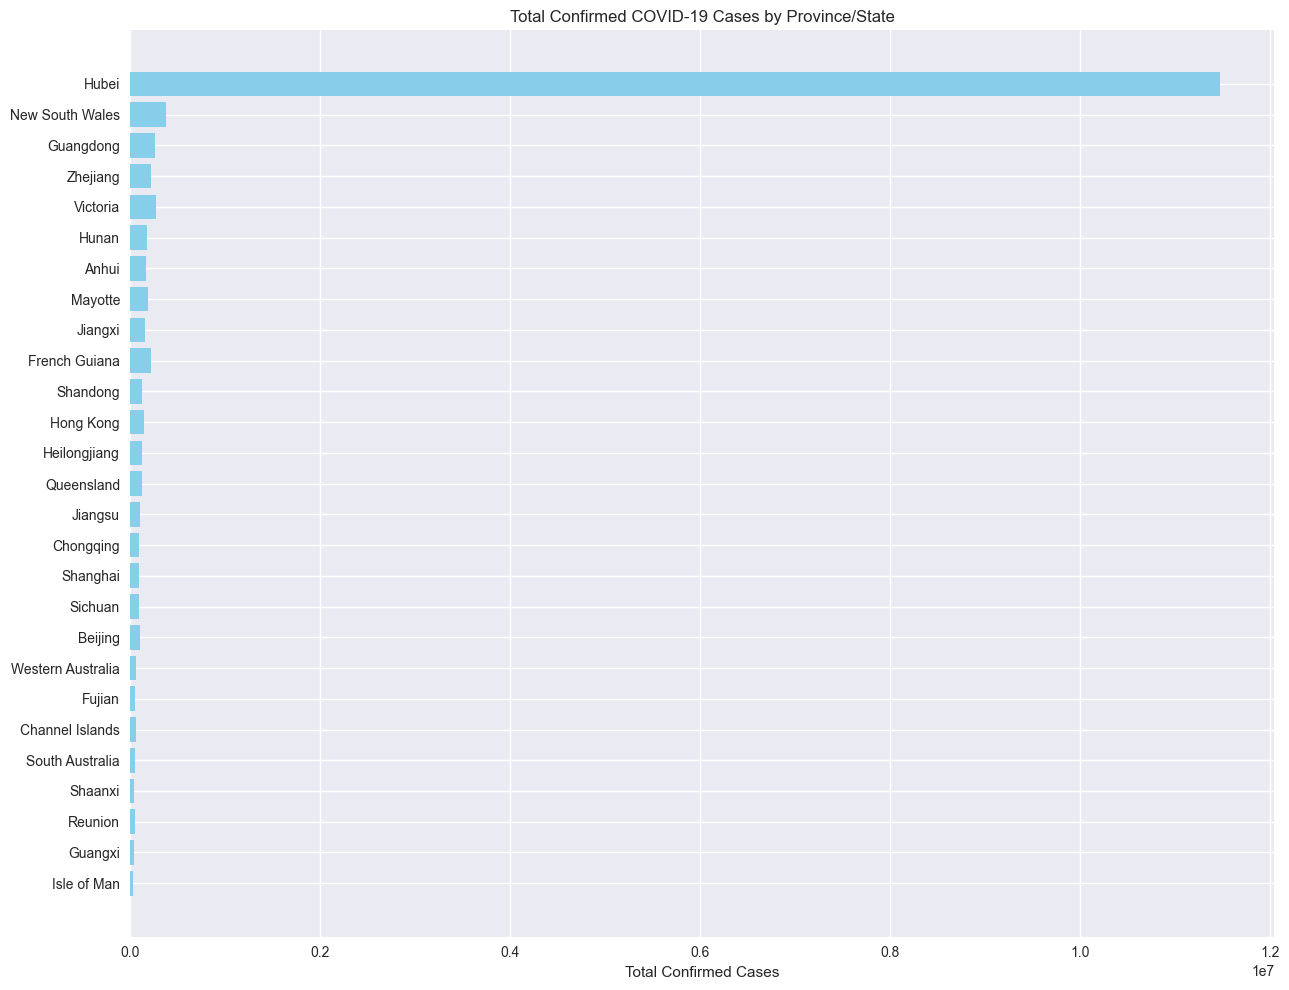

In [199]:
# Create the bar plot
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(13, 10))
plt.barh(top65['Province/State'], top65['tot_Conf'], color='skyblue')
plt.xlabel('Total Confirmed Cases')
plt.title('Total Confirmed COVID-19 Cases by Province/State')
plt.gca().invert_yaxis()  # Highest values on top
plt.tight_layout()
plt.show()

As noted earlier, cases for Hubei are too many, may be because of entry error or may be actual. To represent a proper figure, we will drop the China/Hubei row.

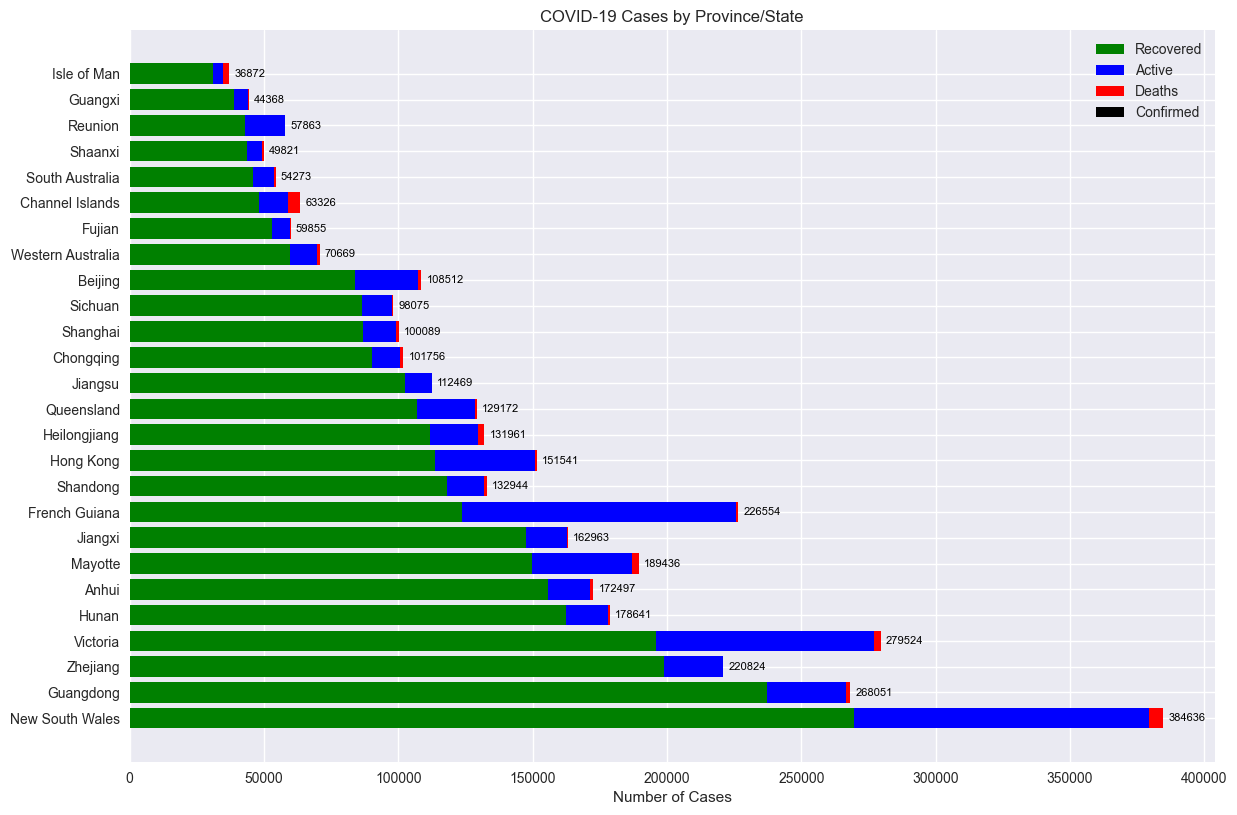

In [200]:
top65.drop(0, inplace=True) # remove the index 0 item
top65.reset_index(drop=True, inplace=True) # reset the index again

# Create the horizontal stacked bar plot
fig, ax = plt.subplots(figsize=(14, 9.5))

# Plot each component

ax.barh(top65['Province/State'], top65['tot_Recovered'], color='green', label='Recovered')
ax.barh(top65['Province/State'], top65['tot_Active'], left=top65['tot_Recovered'], color='blue', label='Active')
ax.barh(top65['Province/State'], top65['tot_Deaths'], left=top65['tot_Recovered'] + top65['tot_Active'], color='red', label='Deaths')
ax.barh(0, 0, color='black', label='Confirmed')

# Add labels and legend
ax.set_xlabel('Number of Cases')
ax.set_title('COVID-19 Cases by Province/State')
ax.legend(loc='upper right')

# Annotate total confirmed cases at the end of each bar
for i, total in enumerate(top65['tot_Conf']):
    ax.text(total + 2000, i, str(total), va='center', fontsize=8, color='black')

plt.show()


#### Key Observations
Regions like **French Guiana** and **New South Wales** show large active case segments, highlighting *ongoing infections*.

**Channel Islands** and **Isle of Man** have relatively high death proportions compared to their *total confirmed cases*.

Many Chinese provinces (e.g., **Zhejiang, Guangdong**) show strong recovery segments, indicating *effective containment and treatment*.

### Prediction Model Development

<hr>
Prediction Model Development using Facebook's Prophet
<hr>

Prophet is a very user-friendly - it handles seasonality and holiday effects with minimal setup.   
Time series forecasting isn’t just about accuracy - interpretability and communication are key. Small changes in parameters or preprocessing can drastically affect long-term forecasts. Real-world data is messy and requires thoughtful wrangling. **Prophet** is a procedure for forecasting time series data based on an additive model where non-linear trends are fit with yearly, weekly, and daily seasonality, plus holiday effects. It works best with time series that have strong seasonal effects and several seasons of historical data. Prophet is robust to missing data and shifts in the trend, and typically handles outliers well.

In [201]:
from prophet import Prophet # also pip-install plotly. it is dependent
model= Prophet()

In [202]:
df_confirmed= pd.DataFrame(datewise_toll_df.Confirmed)

        # Important to rename the columns.
        # it is the requirement of Prophet structure
df_confirmed.index.name= 'ds'
df_confirmed.rename(columns={'Confirmed':'y'}, inplace=True)

        # and it is also mandatory to have the date (ds) and target (y) columns seperate
        # it should not be a part of index
df_confirmed.reset_index(inplace=True)

df_confirmed.head()

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118


In [203]:
model.fit(df_confirmed)

22:18:02 - cmdstanpy - INFO - Chain [1] start processing
22:18:02 - cmdstanpy - INFO - Chain [1] done processing


In [204]:
future= model.make_future_dataframe(periods=7)
forecast_data= model.predict(future)
forecast_data

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-22,-9.356181e+03,-1.262293e+05,8.527034e+04,-9.356181e+03,-9.356181e+03,-10986.215104,-10986.215104,-10986.215104,-10986.215104,-10986.215104,-10986.215104,0.0,0.0,0.0,-2.034240e+04
1,2020-01-23,-6.667726e+03,-1.191437e+05,9.616874e+04,-6.667726e+03,-6.667726e+03,-1078.892495,-1078.892495,-1078.892495,-1078.892495,-1078.892495,-1078.892495,0.0,0.0,0.0,-7.746619e+03
2,2020-01-24,-3.979272e+03,-9.771621e+04,1.047877e+05,-3.979272e+03,-3.979272e+03,10103.254163,10103.254163,10103.254163,10103.254163,10103.254163,10103.254163,0.0,0.0,0.0,6.123982e+03
3,2020-01-25,-1.290817e+03,-9.331783e+04,1.161065e+05,-1.290817e+03,-1.290817e+03,13670.219215,13670.219215,13670.219215,13670.219215,13670.219215,13670.219215,0.0,0.0,0.0,1.237940e+04
4,2020-01-26,1.397637e+03,-1.024612e+05,1.072066e+05,1.397637e+03,1.397637e+03,7218.147794,7218.147794,7218.147794,7218.147794,7218.147794,7218.147794,0.0,0.0,0.0,8.615785e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,2020-07-30,1.674928e+07,1.664025e+07,1.686156e+07,1.674260e+07,1.675507e+07,-1078.892495,-1078.892495,-1078.892495,-1078.892495,-1078.892495,-1078.892495,0.0,0.0,0.0,1.674820e+07
191,2020-07-31,1.695352e+07,1.684956e+07,1.706819e+07,1.694156e+07,1.696644e+07,10103.254163,10103.254163,10103.254163,10103.254163,10103.254163,10103.254163,0.0,0.0,0.0,1.696362e+07
192,2020-08-01,1.715776e+07,1.705978e+07,1.728365e+07,1.713549e+07,1.717968e+07,13670.219215,13670.219215,13670.219215,13670.219215,13670.219215,13670.219215,0.0,0.0,0.0,1.717143e+07
193,2020-08-02,1.736200e+07,1.725388e+07,1.748231e+07,1.732735e+07,1.739381e+07,7218.147794,7218.147794,7218.147794,7218.147794,7218.147794,7218.147794,0.0,0.0,0.0,1.736922e+07


In [205]:
forecast_data[['yhat_lower', 'yhat', 'yhat_upper']]

,yhat_lower,yhat,yhat_upper
0,-1.262293e+05,-2.034240e+04,8.527034e+04
1,-1.191437e+05,-7.746619e+03,9.616874e+04
2,-9.771621e+04,6.123982e+03,1.047877e+05
3,-9.331783e+04,1.237940e+04,1.161065e+05
4,-1.024612e+05,8.615785e+03,1.072066e+05
...,...,...,...
190,1.664025e+07,1.674820e+07,1.686156e+07
191,1.684956e+07,1.696362e+07,1.706819e+07
192,1.705978e+07,1.717143e+07,1.728365e+07
193,1.725388e+07,1.736922e+07,1.748231e+07


#### Key Observations
* **ds** contains the dates for which the predictions have been made. It stands for "date stamp."
* **yhat** is the predicted value (forecast) for the given date in the ds column. It represents the model's best estimate for that point in time.
* **yhat_upper** represents the upper bound of the predicted value, which indicates the higher end of the confidence interval.

It suggests that the actual value is unlikely to exceed this amount, giving you an idea of the prediction's uncertainty.

**yhat_lower** column represents the lower bound of the predicted value, indicating the lower end of the confidence interval. It suggests that the actual value is unlikely to be lower than this amount.

<Figure size 1600x550 with 0 Axes>

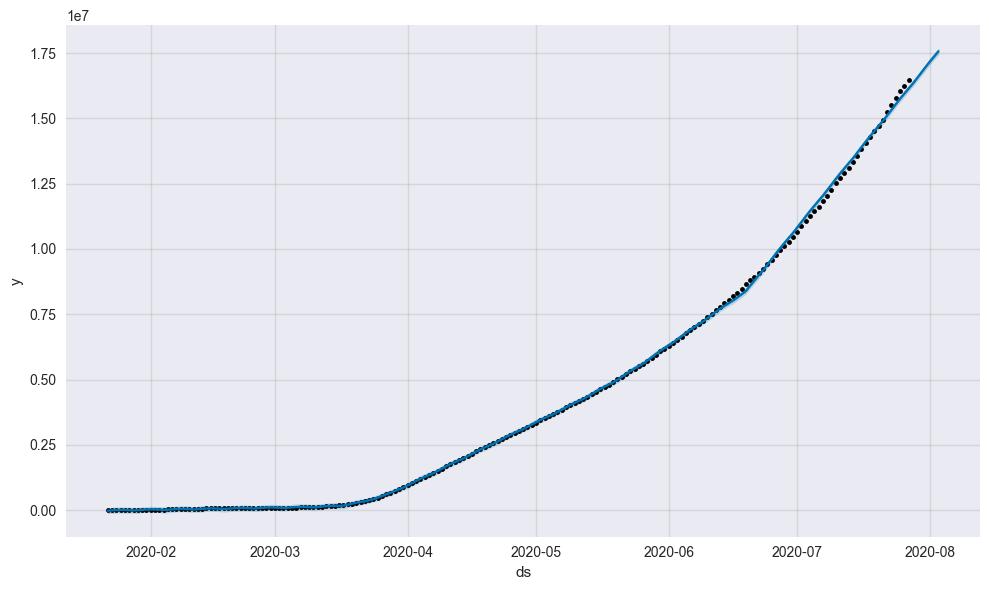

In [206]:
plt.figure(figsize=(16,5.5))
model.plot(forecast_data)
plt.show()

In [207]:
import plotly
import plotly.express as ex

world=covid19_df.groupby(['Country/Region'])[['Confirmed', 'Deaths', 'Recovered', 'Active']].sum().reset_index()
world

,Country/Region,Confirmed,Deaths,Recovered,Active
0,Afghanistan,1936390,49098,798240,1089052
1,Albania,196702,5708,118877,72117
2,Algeria,1179755,77972,755897,345886
3,Andorra,94404,5423,69074,19907
4,Angola,22662,1078,6573,15011
...,...,...,...,...,...
182,West Bank and Gaza,233461,1370,61124,170967
183,Western Sahara,901,63,648,190
184,Yemen,67180,17707,23779,25694
185,Zambia,129421,2643,83611,43167


In [208]:
figure = ex.choropleth(world,
                       locations='Country/Region',
                       locationmode='country names',
                       color='Active',
                       hover_name='Country/Region',
                       range_color=[1,10000],
                       color_continuous_scale='reds',
                       title='COVID-19 World map')

# Change figure size in pixels
figure.update_layout(width=1024,
                     height=768)

figure.show()